<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/EXP_6_Variational_Autoencoders_(VAEs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cell 1: Imports and Hyperparameters
In this cell, we import the necessary PyTorch modules and set the random seeds for reproducibility. We also define the latent_dim = 2, which forces the model to compress the $28 \times 28$ images into just two numbers. This is what allows us to visualize the results on a 2D scatter plot later.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim = 2  # 2D for easy visualization
batch_size = 128
num_epochs = 20

print(f"Using device: {device}")

Using device: cuda


#Cell 2: Dataset PreparationWe load the standard MNIST dataset.
We only use a simple ToTensor transform here because VAEs typically use a Sigmoid activation in the final layer of the decoder, which expects pixel values to be in the range $[0, 1]$.

In [ ]:
# Transform: Convert to tensor (range 0 to 1)
transform = transforms.Compose([transforms.ToTensor()])

# Download and Load MNIST
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset loaded: {len(train_dataset)} training images.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

Dataset loaded: 60000 training images.


#Cell 3: Defining the VAE Architecture
The VAE consists of two main parts:

1)The Encoder: Compresses the image into two parameters: Mean ($\mu$) and Log-Variance ($\sigma$).

2)The Reparameterization Trick: A critical VAE step that allows backpropagation by sampling from the distribution $z = \mu + \epsilon \cdot \sigma$.

3)The Decoder: Takes the sampled point $z$ and tries to reconstruct the original image.

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: Flatten 28x28 -> 512 -> 256
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder: Latent 2 -> 256 -> 512 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid() # Outputs values between 0 and 1
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

model = VAE().to(device)
print(model)

VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


#Cell 4: Loss Function and Training Loop
The VAE loss is unique. It combines Binary Cross Entropy (BCE), which ensures the reconstruction looks like the original, and Kullback-Leibler Divergence (KLD), which acts as a regularizer to ensure the latent space is normally distributed and smooth.

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction Loss
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # Regularization Loss (KL Divergence)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Starting VAE training...")
for epoch in range(num_epochs):
    total_loss = 0
    for data in train_loader:
        img, _ = data
        img = img.to(device)

        recon, mu, logvar = model(img)
        loss = vae_loss(recon, img, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Avg Loss: {total_loss/len(train_loader):.4f}')

print("Training completed!")

Starting VAE training...
Epoch [1/20], Avg Loss: 23304.7554
Epoch [2/20], Avg Loss: 20456.7629
Epoch [3/20], Avg Loss: 19739.2348
Epoch [4/20], Avg Loss: 19287.3605
Epoch [5/20], Avg Loss: 19032.6776
Epoch [6/20], Avg Loss: 18838.3679
Epoch [7/20], Avg Loss: 18655.1055
Epoch [8/20], Avg Loss: 18518.9386
Epoch [9/20], Avg Loss: 18404.8193
Epoch [10/20], Avg Loss: 18277.2477
Epoch [11/20], Avg Loss: 18201.2213
Epoch [12/20], Avg Loss: 18136.7635
Epoch [13/20], Avg Loss: 18066.7100
Epoch [14/20], Avg Loss: 18014.3067
Epoch [15/20], Avg Loss: 17940.4180
Epoch [16/20], Avg Loss: 17886.4966
Epoch [17/20], Avg Loss: 17861.7773
Epoch [18/20], Avg Loss: 17824.3457
Epoch [19/20], Avg Loss: 17796.1749
Epoch [20/20], Avg Loss: 17738.7689
Training completed!


#Cell 5: Visualizing Reconstruction and Latent Space
This cell produces two visualizations:

1)Image Comparison: We pass 10 test images through the model to see how well the VAE can reconstruct them after compressing them to 2D.

2)Latent Space Map: We plot the 2D coordinates $(\mu_1, \mu_2)$ for several images and color them by their digit class. You should see distinct clusters for different digits!

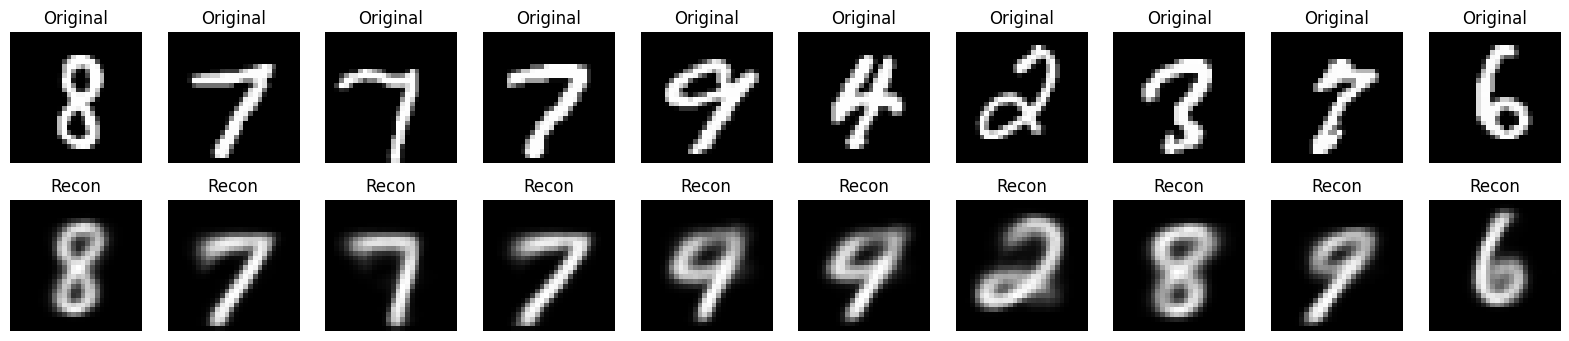

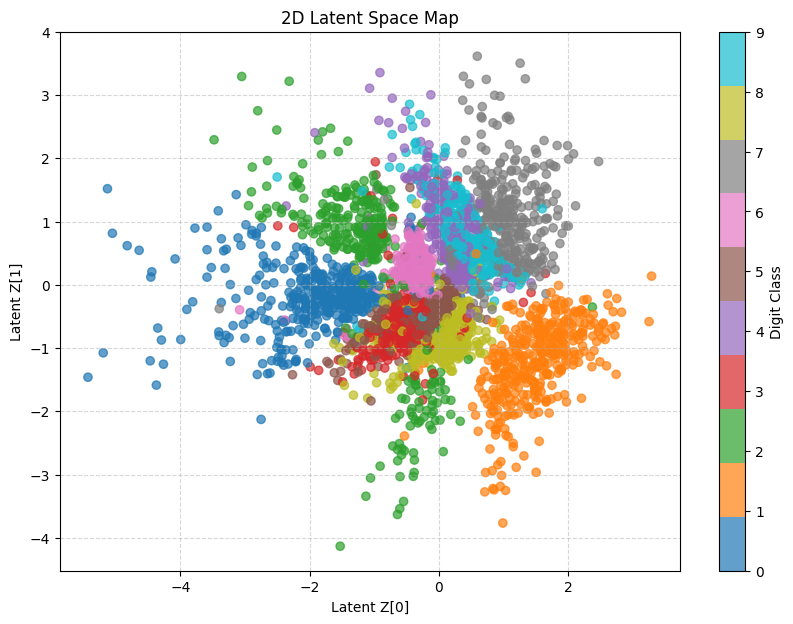

In [ ]:
model.eval()

# 1. Show Original vs Reconstructed
with torch.no_grad():
    test_images, labels = next(iter(train_loader))
    test_images = test_images[:10].to(device)
    recon_images, mu, _ = model(test_images)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    orig = test_images[i].cpu().view(28, 28).numpy()
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    recon = recon_images[i].cpu().view(28, 28).numpy()
    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Recon")
plt.show()

# 2. Show 2D Latent Space
all_mu = []
all_labels = []
with torch.no_grad():
    for data, lbl in train_loader:
        _, mu, _ = model(data.to(device))
        all_mu.append(mu.cpu())
        all_labels.extend(lbl.numpy())
        if len(all_mu) > 25: break # Sample for visualization

all_mu = torch.cat(all_mu)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit Class')
plt.title("2D Latent Space Map")
plt.xlabel("Latent Z[0]")
plt.ylabel("Latent Z[1]")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()